# Домашнее задание 2. Работа с изображениями

В этом задании предлагается решить простейшую задачу рапознавания лиц. Вам нужно будет научить модель для пары картинок определять, разные ли люди на них изображены.

Работать будем с датасетом фотографий известных людей. Скачать его можно [тут](https://disk.360.yandex.ru/d/oAmJgPESjP33hg). В нём представлены 150 человек, для каждого по 6-9 фотографий. Всего около 1000 изображений.

__Задание__. Вам потребуется выполнить два задания:

1) Реализовать модель бинарной классификации и добиться приемлемого качества.

2) Реализовать триплетную функцию потерь и улучшить качество предсказаний с ее помощью.

Напишите краткий отчёт о проделанных экспериментах. Что сработало и что не сработало? Почему вы решили, сделать так, а не иначе? Обязательно указывайте ссылки на чужой код, если вы его используете. Обязательно ссылайтесь на статьи / блогпосты / вопросы на stackoverflow / видосы от ютуберов-машинлернеров / курсы / подсказки от Дяди Васи и прочие дополнительные материалы, если вы их используете.

__Во всех заданиях будем придерживаться следующих правил__:
1. Использовать внешние данные для обучения строго запрещено. Также запрещено обучаться на валидационной выборке.
2. Все задания должны быть выполнены без использования предобученных моделей и готовых реализаций. Тем не менее:
    - В заданиях, где требуется достичь некоторого качества модели, разрешается использовать предобученные модели. Но __оценка за задние будет снижена__ (для каждого задания будет отдельно указано, на сколько).
    - В некоторых заданиях может сильно помочь библотека [pytorch-metric-learning](https://kevinmusgrave.github.io/pytorch-metric-learning/). Вы можете использовать готовые реализации из неё, но __максимальный балл за задание также будет снижен__.

__Советы и указания__:
 - Наверняка вам потребуется много гуглить о том, как заставить это всё работать. Это нормально, все гуглят. Но не забывайте, что нужно быть готовым за скатанный код отвечать :)
 - Рекомендуем использовать шаблоны ниже. Однако делать это мы не заставляем. Если вам так неудобно, то можете писать код в удобном стиле. Однако учтите, что чрезмерное изменение нижеперечисленных шаблонов увеличит количество вопросов к вашему коду :)
 - Валидируйте. Трекайте ошибки как можно раньше, чтобы не тратить время впустую.
 - Чтобы быстро отладить код, пробуйте обучаться на маленькой части датасета (скажем, 5-10 картинок просто чтобы убедиться что код запускается). Когда вы поняли, что смогли всё отдебажить, переходите обучению по всему датасету
 - На каждый запуск делайте ровно одно изменение в модели/аугментации/оптимайзере, чтобы понять, что и как влияет на результат.
 - Фиксируйте random seed.
 - Правильно нормализуйте данные при создании, пример [тык, но тут и в целом гайд от и до](https://www.pluralsight.com/guides/image-classification-with-pytorch)
 - Начинайте с простых моделей и постепенно переходите к сложным. Обучение лёгких моделей экономит много времени. Можно написать свою модель руками, а можно импортировать не предобученную сетку известной архитектуры из модуля `torchvision.models`. Один из способов как можно сделать: [документация (полезная)](https://pytorch.org/vision/stable/models.html)
 - Используйте все возможные методы оптимизации и эксперемнтируйте с ними.
 - Ставьте расписание на learning rate. Уменьшайте его, когда лосс на валидации перестаёт убывать.
 - Model Checkpointing. Сохраняйте свой прогресс (модели), чтобы когда что-то пойдет не так вы сможете начать с этого места или просто воспроизвести свои результаты модели, которые обучали.
    * Пример как можно с wandb тут: [Сохраняем лучшие модели в wandb](https://docs.wandb.ai/guides/integrations/lightning)
    * По простому можно так: [Сохраняем модели в pytorch дока](https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 - Советуем использовать GPU. Если у вас его нет, используйте google colab. Если вам неудобно его использовать на постоянной основе, напишите и отладьте весь код локально на CPU, а затем запустите уже написанный ноутбук в колабе.

Good luck & have fun! :)

In [38]:
import os
import tqdm
import numpy
import torch
import pandas
import random
import torchvision
import sklearn.metrics
import torch.utils.data
import matplotlib.pyplot as plt
import torchvision.transforms.v2

In [39]:
# Обязательно вызывайте эту функцию перед каждый запуском обучения!
# Если проверяющий не сможет воспроизвести результат, оценка за задание будет снижена.
def set_random_seed(seed: int = 42):
    random.seed(seed)
    numpy.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### [1.5 балла] Часть 1. Подготовка данных.

##### [0.5 балла] Задание 1.1. Считать датасет.

Сначала нужно считать датасет с фотографиями и посмотреть на его устройство.

In [40]:
import zipfile

with zipfile.ZipFile('data.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

transform = torchvision.transforms.Compose([
    # torchvision.transforms.Resize((32, 32)),
    torchvision.transforms.ToTensor(),
])

train_ds = torchvision.datasets.ImageFolder("data/training", transform=transform)
test_ds = torchvision.datasets.ImageFolder("data/testing", transform=transform)


In [ ]:
train_ds.classes

['Al_Gore',
 'Al_Sharpton',
 'Ali_Naimi',
 'Amelia_Vega',
 'Ana_Guevara',
 'Ana_Palacio',
 'Angela_Bassett',
 'Antonio_Palocci',
 'Arminio_Fraga',
 'Ben_Affleck',
 'Bill_Frist',
 'Bill_Graham',
 'Billy_Crystal',
 'Binyamin_Ben-Eliezer',
 'Bob_Graham',
 'Bob_Hope',
 'Bob_Stoops',
 'Boris_Becker',
 'Bulent_Ecevit',
 'Calista_Flockhart',
 'Carmen_Electra',
 'Celine_Dion',
 'Cesar_Gaviria',
 'Charles_Taylor',
 'Charlton_Heston',
 'Christine_Todd_Whitman',
 'Clay_Aiken',
 'Clint_Eastwood',
 'Colin_Farrell',
 'Costas_Simitis',
 'David_Wells',
 'Dennis_Hastert',
 'Dennis_Kucinich',
 'Diana_Krall',
 'Edward_Lu',
 'Elsa_Zylberstein',
 'Elton_John',
 'Fernando_Gonzalez',
 'Fernando_Henrique_Cardoso',
 'Fujio_Cho',
 'Geoff_Hoon',
 'George_Clooney',
 'Gerry_Adams',
 'Goldie_Hawn',
 'Gunter_Pleuger',
 'Gwyneth_Paltrow',
 'Heizo_Takenaka',
 'Holly_Hunter',
 'Hosni_Mubarak',
 'Hugh_Grant',
 'JK_Rowling',
 'Jan_Ullrich',
 'Jay_Garner',
 'Jean-Pierre_Raffarin',
 'Jelena_Dokic',
 'Jeong_Se-hyun',
 'Jess

used: \
https://docs.pytorch.org/vision/stable/transforms.html \
https://www.youtube.com/watch?v=Zvd276j9sZ8

Давайте посмотрим на примеры фотографий. Нарисуйте несколько.

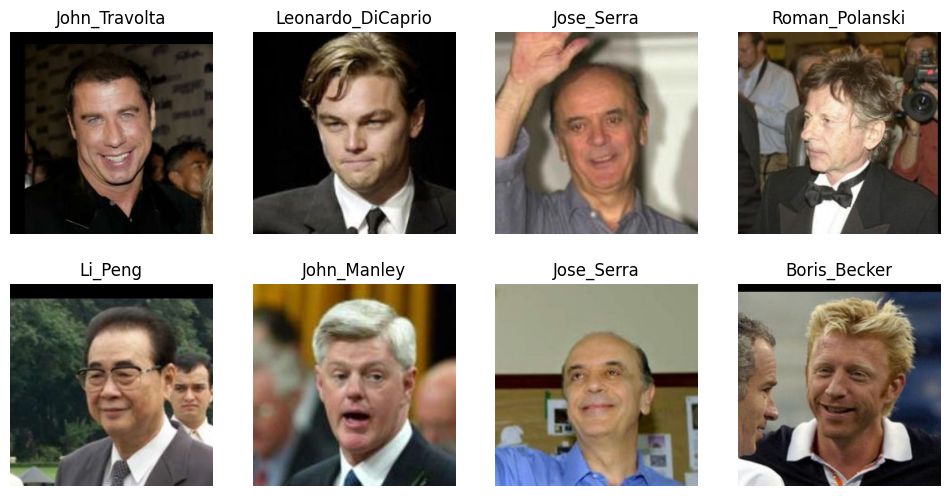

1065


In [41]:
indices = torch.randperm(len(train_ds))[:8]
plt.figure(figsize=(12, 6))
for i, idx in enumerate(indices):
    img, label = train_ds[idx]
    class_name = train_ds.classes[label]
    plt.subplot(2, 4, i+1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(class_name)
    plt.axis('off')
plt.show()

print(len(train_ds))


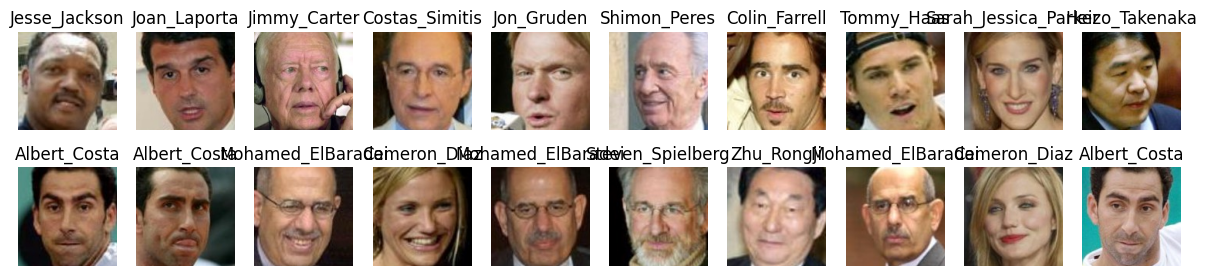

In [ ]:
### YOUR CODE HERE ###

Наконец, следует вывести распределение фотографий по людям и убедиться, что для каждого человека действительно предствалено 6-9 фотографий.

/tmp/ipython-input-3648860956.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


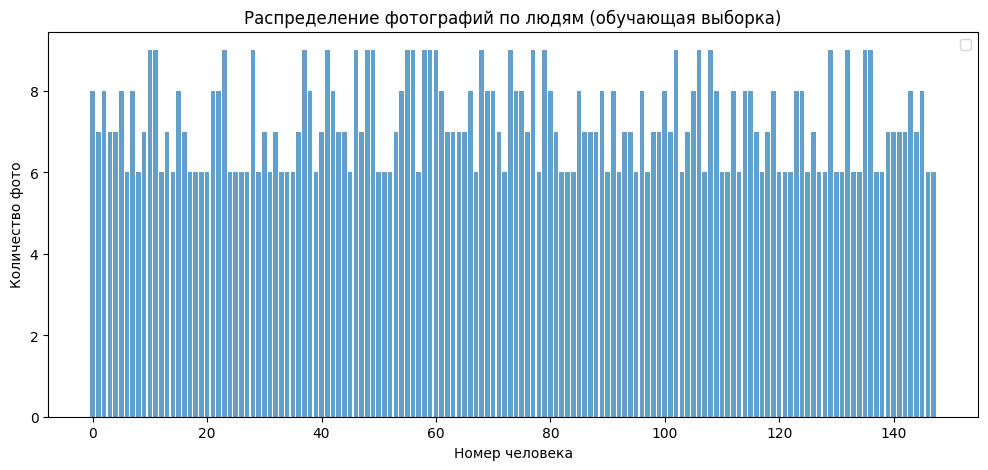

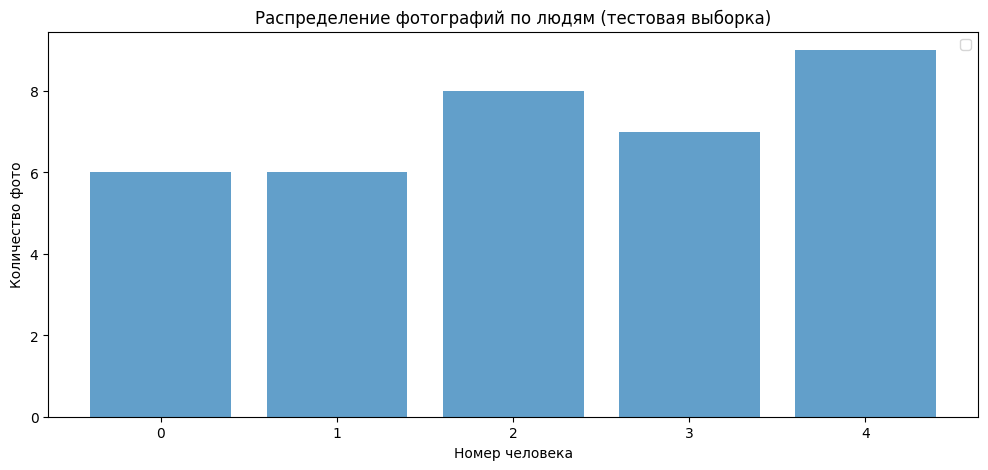

In [43]:
def show_photo_distribtion(targets, title):
    from collections import Counter

    counts = list(Counter(targets).values())

    plt.figure(figsize=(12, 5))
    plt.title(f'Распределение фотографий по людям ({title})')
    plt.bar(range(len(counts)), counts, alpha=0.7)
    plt.xlabel('Номер человека')
    plt.ylabel('Количество фото')
    plt.legend()
    plt.show()

show_photo_distribtion(train_ds.targets, "обучающая выборка")
show_photo_distribtion(test_ds.targets, "тестовая выборка")

##### [0 баллов] Задание 1.2. Датасет пар.

Как было сказано ранее, мы будем обучать модели предсказывать, разные ли люди изображены на фотографиях. Для этого нам надо научиться формировать пары фотографий и целевую переменную из двух классов: 0 и 1. \
Класс 0 означает, что это фотографии одного человека. \
Класс 1 означает фотографии разных людей. \
 \
К счастью, весь датасет уже написан.

In [44]:
def show_class_distribtion(targets):
    from collections import Counter

    counts = list(Counter(targets).values())
    plt.figure(figsize=(12, 5))
    plt.bar(range(len(counts)), counts, alpha=0.7)

    plt.legend()
    plt.show()

In [45]:
class PairDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.targets = [ self._get_target(i) for i in tqdm.trange(len(self)) ]

    def _idx1(self, idx):
        return idx % len(self.dataset)

    def _idx2(self, idx):
        return idx // len(self.dataset)

    def _get_target(self, idx):
        return int(self.dataset.targets[self._idx1(idx)] != self.dataset.targets[self._idx2(idx)])

    def __len__(self):
        return len(self.dataset) ** 2

    def __getitem__(self, idx):
        image1, label1 = self.dataset[self._idx1(idx)]
        image2, label2 = self.dataset[self._idx2(idx)]
        return image1, image2, int(label1 != label2)

train_pairs = PairDataset(train_ds)
test_pairs = PairDataset(test_ds)

100%|██████████| 1296/1296 [00:00<00:00, 1508692.20it/s]


/tmp/ipython-input-1484931937.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


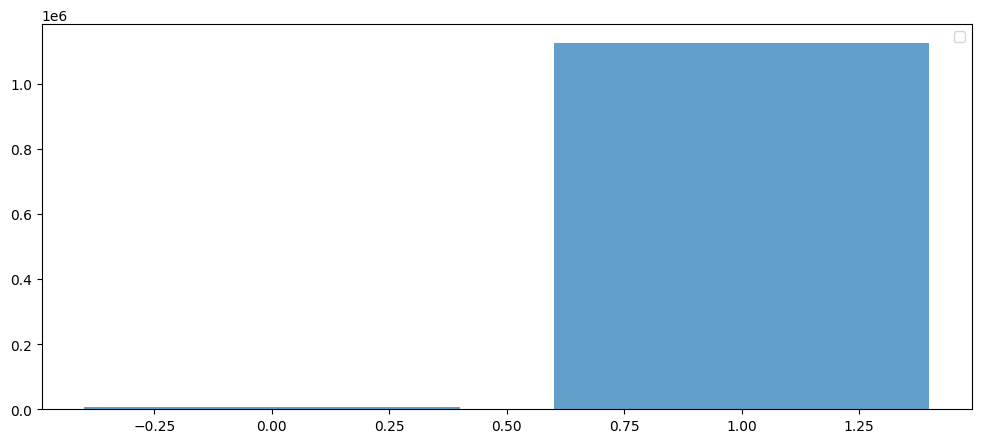

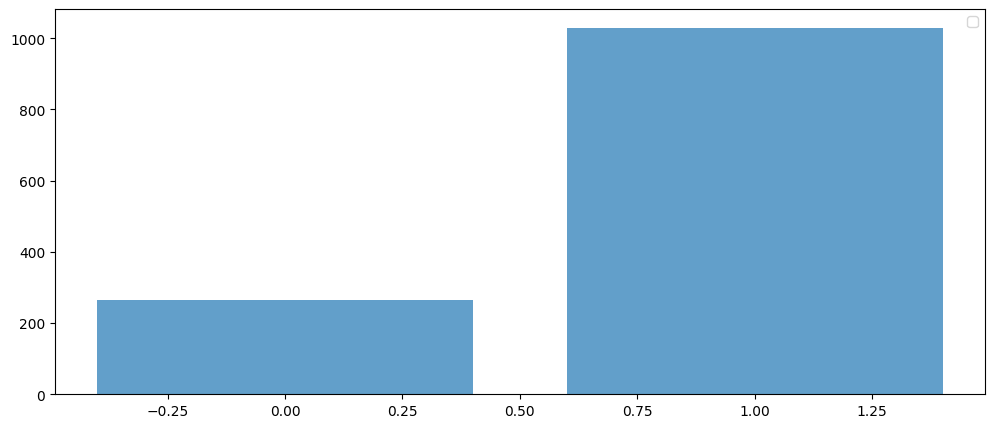

In [46]:
show_class_distribtion(train_pairs.targets)
show_class_distribtion(test_pairs.targets)

Легко видеть, что пар фотографий разных людей гораздо больше, чем пар фотографий одного человека. Это вполне ожидаемо, но, если не предпринять мер, ведет к двум проблемам:
1. Метрика качества предсказаний должна учитывать дисбаланс классов. В частности, accuracy нам не подойдёт. А использовать будем известный из курса машинного обучения AUC-ROC.
2. Нужно "подтюнить" даталоадер тренировочных данных, чтобы в каждый батч попадало примерно одинаковое количество фотографий каждого класса. Иначе победить деградацию модели к "всегда 1" будет очень сложно.

##### [1 балл] Задание 1.3. Стратифицированный даталоадер.

Для начала решим вторую проблему. Нужно сделать такой даталоадер, чтобы в каждом батче количество элементов класса "0" совпадало с количеством элементов класса "1".

Как известно, стандартный класс `DataLoader` в torch имеет много параметров. В частности, параметр `sampler` позволяет гибко управлять выдачей. Изучите [документацию](https://docs.pytorch.org/docs/stable/data.html#data-loading-order-and-sampler) и реализуйте свой семплер, который решит проблему.

В `pytorch_metric_learning` уже есть готовая реализация того, что нам нужно. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.4__.

In [47]:
class StratifiedPairSampler(torch.utils.data.Sampler):
    def __init__(self, dataset, batch_size):
        self.dataset = dataset
        self.batch_size = batch_size

        self.class0_indices = [i for i, target in enumerate(dataset.targets) if target == 0]
        self.class1_indices = [i for i, target in enumerate(dataset.targets) if target == 1]

        assert batch_size % 2 == 0, "Batch size must be even"

        self.num_batches = min(len(self.class0_indices), len(self.class1_indices)) * 2 // batch_size
        self.length = self.num_batches * batch_size

    def __iter__(self):
        class0_shuffled = self.class0_indices.copy()
        class1_shuffled = self.class1_indices.copy()
        random.shuffle(class0_shuffled)
        random.shuffle(class1_shuffled)

        indices = []
        half_batch = self.batch_size // 2

        for i in range(self.num_batches):
            start_idx = i * half_batch
            end_idx = (i + 1) * half_batch
            indices.extend(class0_shuffled[start_idx:end_idx])
            indices.extend(class1_shuffled[start_idx:end_idx])

        return iter(indices)

    def __len__(self):
        return self.length

In [48]:
def show_class_distribtion(targets):
    from collections import Counter

    # Если targets - тензор, преобразуем в обычный список
    if torch.is_tensor(targets):
        targets = targets.cpu().numpy().tolist()

    # Считаем количество каждого класса
    counts = Counter(targets)

    plt.figure(figsize=(8, 4))
    plt.bar(counts.keys(), counts.values(), alpha=0.7, width=0.5)
    plt.xlabel('Класс')
    plt.ylabel('Количество')
    plt.title(f'Распределение классов: {dict(counts)}')
    plt.xticks(list(counts.keys()))
    plt.grid(True, alpha=0.3)
    plt.show()

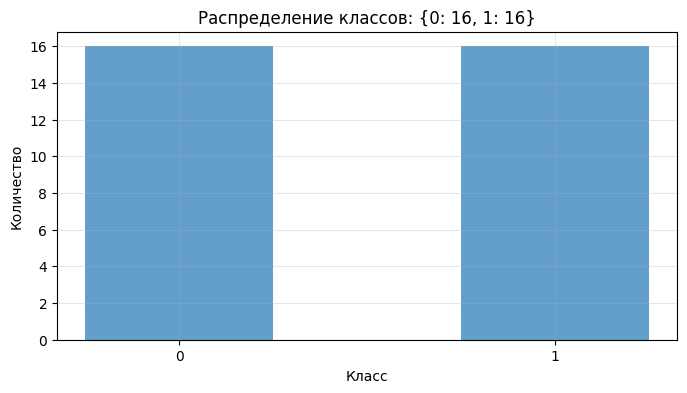

In [49]:
train_pairs_sampler = StratifiedPairSampler(train_pairs, batch_size=32)
train_pairs_loader = torch.utils.data.DataLoader(train_pairs, batch_size=32, sampler=train_pairs_sampler)
test_pairs_loader = torch.utils.data.DataLoader(test_pairs, batch_size=64, shuffle=False)

# Убедимся, что теперь выдача равномерная.
show_class_distribtion(next(iter(train_pairs_loader))[2])

Также использовались источники: \
https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.Sampler \
https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html

### [3.5 балла] Часть 2. Классификация.

Начнём с простого: попробуем решить проблему как обычную задачу бинарной классификации. Реализуйте и обучите обычную свёрточную сеть, которая принимает два набора фотографий и предсказывает вероятность, что это фотографии разных людей.

##### [1 балл] Задание 2.1. Модель классификации.

Сначала нужно реализовать модель. В `forward` необходимо принять два батча фотографий. `i`-e число в выводе `forward` должно быть предсказанием для пары из `i`-й фотографии `image1` и `i`-й фотографии `image2`. Подумайте, как это сделать. Возможно, стоит как-нибудь склеить `image1` и `image2`? Или склеить эмбеддинги? А может быть нужен какой-то трешхолд?

Вы вольны использовать любую архитектуру сети. Ассерт в конце ячейки поможет вам убедиться, что модель теоретически делает то, что нужно.

In [14]:
class ClassificationNet(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.features = torch.nn.Sequential(
            torch.nn.Conv2d(6, 32, 3, padding=1),  # 6 каналов = 3+3
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),

            torch.nn.Conv2d(32, 64, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),

            torch.nn.Conv2d(64, 128, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool2d((4, 4))
        )

        self.classifier = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(128 * 4 * 4, 256),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(256, 1),
            torch.nn.Sigmoid()
        )

    def forward(self, image1, image2):
        # Склеиваем изображения по каналам
        # image1.shape: [batch, 3, H, W], image2.shape: [batch, 3, H, W]
        # -> combined.shape: [batch, 6, H, W]
        combined = torch.cat([image1, image2], dim=1)
        return self.classifier(self.features(combined)).squeeze(1)

# Вы можете использовать этот ассерт в качестве теста, что ваша модель делает то, что нужно.
assert ClassificationNet()(*next(iter(train_pairs_loader))[:2]).shape == (32,)

источники: \
https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html (базовые архитектуры) \
https://docs.pytorch.org/docs/stable/generated/torch.cat.html

##### [2 балла] Задание 2.2. Обучение.

Теперь обучите свою модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 2.5 \cdot \dfrac{AucRoc - 0.6}{0.2}, 2.5) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.8`

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1)

Начинаем обучение...


Epoch 1/5: 100%|██████████| 490/490 [01:24<00:00,  5.16it/s, Loss=0.6984, Avg Loss=0.6153]
                                                                                          
Training Progress:  20%|██        | 1/5 [01:30<06:03, 90.82s/it, Loss=0.6153, AUC=0.7478, Best AUC=0.7478]


Epoch [1/5], Loss: 0.6153, Test AUC: 0.7478



Epoch 2/5: 100%|██████████| 490/490 [01:26<00:00,  5.75it/s, Loss=0.6086, Avg Loss=0.5903]
                                                                                          
Training Progress:  40%|████      | 2/5 [03:02<04:33, 91.32s/it, Loss=0.5903, AUC=0.7984, Best AUC=0.7984]


Epoch [2/5], Loss: 0.5903, Test AUC: 0.7984



Epoch 3/5: 100%|██████████| 490/490 [01:27<00:00,  5.66it/s, Loss=0.5144, Avg Loss=0.5780]
                                                                                          
Training Progress:  40%|████      | 2/5 [04:36<06:54, 138.25s/it, Loss=0.5780, AUC=0.8307, Best AUC=0.8307]



Epoch [3/5], Loss: 0.5780, Test AUC: 0.8307
Цель достигнута! AUC-ROC = 0.8307


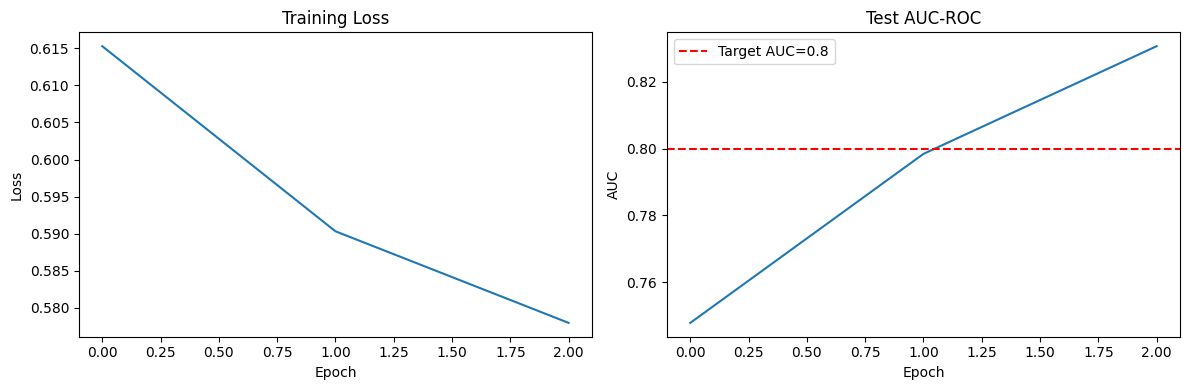

Финальный AUC-ROC: 0.8307
Балл за задание: 2.50


In [ ]:
import torch.optim as optim
from sklearn.metrics import roc_auc_score
import tqdm

def train_model(model, train_loader, test_loader, num_epochs=5):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    criterion = torch.nn.BCELoss()

    train_losses = []
    test_aucs = []

    epoch_pbar = tqdm.tqdm(range(num_epochs), desc="Training Progress", position=0)

    for epoch in epoch_pbar:
        model.train()
        running_loss = 0.0

        batch_pbar = tqdm.tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False, position=1)

        for batch_idx, (image1, image2, labels) in enumerate(batch_pbar):
            image1, image2, labels = image1.to(device), image2.to(device), labels.float().to(device)

            optimizer.zero_grad()
            outputs = model(image1, image2)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            batch_pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Avg Loss': f'{running_loss/(batch_idx+1):.4f}'
            })

        batch_pbar.close()
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)

        model.eval()
        all_preds = []
        all_labels = []

        eval_pbar = tqdm.tqdm(test_loader, desc="Evaluating", leave=False, position=1)
        with torch.no_grad():
            for image1, image2, labels in eval_pbar:
                image1, image2, labels = image1.to(device), image2.to(device), labels.float().to(device)
                outputs = model(image1, image2)
                all_preds.extend(outputs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        eval_pbar.close()
        auc = roc_auc_score(all_labels, all_preds)
        test_aucs.append(auc)

        epoch_pbar.set_postfix({
            'Loss': f'{avg_loss:.4f}',
            'AUC': f'{auc:.4f}',
            'Best AUC': f'{max(test_aucs):.4f}'
        })

        print(f'\nEpoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Test AUC: {auc:.4f}')

        if auc >= 0.8:
            print(f"Цель достигнута! AUC-ROC = {auc:.4f}")
            break

    epoch_pbar.close()
    return model, train_losses, test_aucs

print("Начинаем обучение...")
model = ClassificationNet()
trained_model, train_losses, test_aucs = train_model(model, train_pairs_loader, test_pairs_loader)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(test_aucs)
plt.title('Test AUC-ROC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.axhline(y=0.8, color='r', linestyle='--', label='Target AUC=0.8')
plt.legend()

plt.tight_layout()
plt.show()

final_auc = test_aucs[-1]
score = torch.clamp(torch.tensor(2.5 * (final_auc - 0.6) / 0.2), 0, 2.5)
print(f"Финальный AUC-ROC: {final_auc:.4f}")
print(f"Балл за задание: {score:.2f}")

In [ ]:
model = trained_model

def get_score(auc_roc):
    return max(0, min(2.5 * (auc_roc - 0.6) / 0.2, 2.5))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm.tqdm(test_pairs_loader):
        with torch.no_grad():
            output = your_model(images1.to(device), images2.to(device))
        preds.extend(output.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = numpy.array(preds)
    targets = numpy.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)


final_score = get_score(get_auc_roc(model))

print("AUC_ROC:", get_auc_roc(model))
print(f"Балл за задание: {final_score:.2f}")

100%|██████████| 21/21 [00:05<00:00,  3.62it/s]

AUC_ROC: 0.8306810716110666
Балл за задание: 2.50


##### [0.5 балла] Задание 2.3. Анализ и отчет.

Опишите свои эксперименты. Проанализируйте результаты. Почему результаты получились не очень хорошими? Может быть, решать задачу через бинарную классификацию - не лучшая идея? Приведите не менее 3 аргументов, почему это так.

В ходе экспериментов было трудно обучать модель - это происходило очень долго, ведь датасет очень большой (комбинации лиц). Поэтому я считаю, что в таком варианте решения задачи вычислительные ресурсы используются не очень эффективно: обучаясь на всех парах мы тратим много времени на очевидные случаи, когда люди разные.

Также в бинарной классификации мы просто говорим: человек один на изображениях или нет. Мы не учитываем сходство именно лиц, а бездумно ориентируемся только на датасет.

Также на лекции говорилось о минусе такого подхода в продакшене. Допустим, в такой системе распознавания лиц зарегистрировался новый человек. В случае юинарной классификации, для того, чтобы данный подход смог работать с этим человеком, нужно пересобрать все пары в датасете (снова) и заново обучить (но уже с парами, в которых фигурирует новый человек). Это ОЧЕНЬ затратно и ни одна компания скорее всего не будет этим заниматься.

Также чисто статистически, чем больше людей - тем больше пар изображений, расчете датасет, время на обучение увеличивается, растут затраты.

И еще смысловой недостаток, эта можель просто умеет говорить: эти два лица похожи/не похожи. Она не определяет особые характеристики для какого-то человека.


### [5 баллов] Часть 3. Распознавание лиц.

Теперь попробуем использовать более хитрые методы, которые лучше подходят для решаемой задачи. В частности, триплетную функцию потерь. Далее наша модель будет не предсказывать вероятность для двух картинок, а формировать эмбеддинги для одной картинки таким образом, чтобы эмбеддинги фотографий одного человека были близки, а разных людей - далеки.

##### [2 балла] Задание 3.1. Триплетная функция потерь.

Напомним теорию. Пусть $A$ - произвольное изображение; $P$ - изображение того же человека (позитивный пример); $N$ - изображение любого другого человека (негативный пример); $f$ - наша нейронная сеть; $\alpha$ - гиперпараметр, отвечающий за желаемый “отступ” – расстояние между латентными представлениями изображений разных людей. Тогда функционал ошибки определяется следующим образом:

$$ L(A, P, N) = max(||f(A) - f(P)|| - ||f(A) - f(N)|| + \alpha, 0) $$

В этом задании вам необходимо реализовать этот функционал. Для удобства в дальнейшем, предлагается сразу реализовать batch-версию. Таким образом, на входе должно быть 2 параметра:
- Набор эмбеддингов размера (batch_size, embedding_size)
- Набор классов (номера людей, чьи это фотографии) размера (batch_size)

Ваша функция должна найти все тройки $(A, P, N)$ и вычислить лосс для них.

В `pytorch_metric_learning` уже есть готовая реализация. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.5__.

In [79]:
import torch
import torch.nn as nn

class TripletLoss(nn.Module):
    def __init__(self, margin=0.25):
        super().__init__()
        self.margin = margin

    def forward(self, embeddings, labels):
        device = embeddings.device

        # матрица попарных расстояний (евклидовых)
        distances = torch.cdist(embeddings, embeddings, p=2)

        # позитивные и негативные маски
        mask_pos = (labels.unsqueeze(0) == labels.unsqueeze(1)) & (~torch.eye(len(labels), dtype=bool, device=device))
        mask_neg = labels.unsqueeze(0) != labels.unsqueeze(1)

        triplet_losses = []

        for i in range(len(embeddings)):
            pos_distances = distances[i][mask_pos[i]]
            neg_distances = distances[i][mask_neg[i]]

            if len(pos_distances) == 0 or len(neg_distances) == 0:
                continue

            ap_dist = pos_distances.unsqueeze(1)
            an_dist = neg_distances.unsqueeze(0)

            loss = torch.relu(ap_dist - an_dist + self.margin)
            triplet_losses.append(loss)

        if len(triplet_losses) == 0:
            return torch.tensor(0.0, device=device, requires_grad=True)

        triplet_losses = torch.cat([x.reshape(-1) for x in triplet_losses])
        return triplet_losses.mean()


In [80]:
criterion = TripletLoss(margin=0.25)

In [81]:
# Вы можете использовать этот ассерт в качестве теста
embeddings = torch.tensor([
    [ 1., 2, 3 ],
    [ 1, 3, 4 ],
    [ 4, 5, 6 ]
])
labels = torch.tensor([ 1., 2, 1 ])
loss = criterion(embeddings, labels)
print(f"Computed loss: {loss:.4f}")
print(f"Expected loss: 2.6775")
print(f"Difference: {abs(loss - 2.6775):.4f}")
assert (criterion(embeddings, labels) - 2.6775) < 1e-4

Computed loss: 2.6775
Expected loss: 2.6775
Difference: 0.0000


##### [3 балла] Задание 3.2. Обучение.

Теперь обучите модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 3 \cdot \dfrac{AucRoc - 0.8}{0.15}, 3) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.95`

При необходимости, вы можете улучшить функцию потерь. Например, учитывать не все тройки, а только "сложные", как это умеет делать реализация в `pytorch_metric_learning`. Также подумайте над даталоадером. Возможно, имеет смысл брать в батч одинаковое количество фотографий каждого человека по аналгии с заданием 1.3? Тем не менее имейте в виду, что для получения полного балла за задание, вы должны реализовать все модификации самостоятельно, а не использовать готовые.

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1.5) \
__При использовани pytorch_metric_learning, балл за это задание уменьшается на 0.5 за каждое использование__

In [82]:
class FaceEncoder(torch.nn.Module):
    def __init__(self, embedding_dim=512):
        super().__init__()

        self.features = torch.nn.Sequential(
            torch.nn.Conv2d(3, 64, 3, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.Conv2d(64, 64, 3, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            torch.nn.Dropout2d(0.1),

            torch.nn.Conv2d(64, 128, 3, padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),
            torch.nn.Conv2d(128, 128, 3, padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            torch.nn.Dropout2d(0.1),

            torch.nn.Conv2d(128, 256, 3, padding=1),
            torch.nn.BatchNorm2d(256),
            torch.nn.ReLU(),
            torch.nn.Conv2d(256, 256, 3, padding=1),
            torch.nn.BatchNorm2d(256),
            torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool2d((4, 4))
        )

        self.embedding = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(256 * 4 * 4, 1024),
            torch.nn.BatchNorm1d(1024),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(1024, embedding_dim)
        )

    def forward(self, image1, image2=None):
        if image2 is not None:
            emb1 = self._get_embedding(image1)
            emb2 = self._get_embedding(image2)
            return torch.zeros(image1.size(0), device=image1.device)
        else:
            return self._get_embedding(image1)

    def _get_embedding(self, x):
        features = self.features(x)
        embedding = self.embedding(features)
        return torch.nn.functional.normalize(embedding, p=2, dim=1)

In [83]:
train_simple_loader = torch.utils.data.DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    drop_last=True
)

print(f"Простой даталоадер: {len(train_simple_loader)} батчей за эпоху")

images, labels = next(iter(train_simple_loader))
print(f"Размер батча: {images.shape}")
print(f"Метки: {labels}")
print(f"Уникальные люди в батче: {len(torch.unique(labels))}")

Простой даталоадер: 33 батчей за эпоху
Размер батча: torch.Size([32, 3, 250, 250])
Метки: tensor([ 26,  13,   9,  62,  71,  19,  85,  78, 140, 139,  58, 129,  53,  92,
        101,  52,  56,  51, 126, 121,  16,  21, 115, 122,  48,  73,  61,  98,
        100,  28,  80,  25])
Уникальные люди в батче: 32


In [84]:
from tqdm import tqdm

def get_score(auc_roc):
    return max(0, min(3 * (auc_roc - 0.8) / 0.15, 3))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm(test_pairs_loader):
        with torch.no_grad():
            emb1 = your_model(images1.to(device))
            emb2 = your_model(images2.to(device))
            # Вы можете изменить функцию расстояния между эмбеддингами, если считаете нужным
            dist = ((emb1 - emb2) ** 2).sum(dim = 1)
        preds.extend(dist.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = numpy.array(preds)
    targets = numpy.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

Учимся (250 эпох):

In [85]:
import torch.optim as optim

model = FaceEncoder().to(device)
criterion = TripletLoss(margin=0.25)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 250
eval_every = 25

train_losses = []
test_aucs = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for images, labels in tqdm(train_simple_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)
        embeddings = model(images)
        loss = criterion(embeddings, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_simple_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {avg_loss:.4f}")

    if (epoch + 1) % eval_every == 0:
        auc = get_auc_roc(model)
        test_aucs.append(auc)
        print(f"→ Validation AUC-ROC: {auc:.4f}")

Epoch 1/250: 100%|██████████| 33/33 [00:17<00:00,  1.84it/s]


Epoch [1/250]  Train Loss: 0.2102


Epoch 2/250: 100%|██████████| 33/33 [00:17<00:00,  1.87it/s]


Epoch [2/250]  Train Loss: 0.1643


Epoch 3/250: 100%|██████████| 33/33 [00:17<00:00,  1.88it/s]


...

Epoch [249/250]  Train Loss: 0.0186


Epoch 250/250: 100%|██████████| 33/33 [00:17<00:00,  1.89it/s]


Epoch [250/250]  Train Loss: 0.0344


100%|██████████| 21/21 [00:16<00:00,  1.28it/s]

→ Validation AUC-ROC: 0.9308


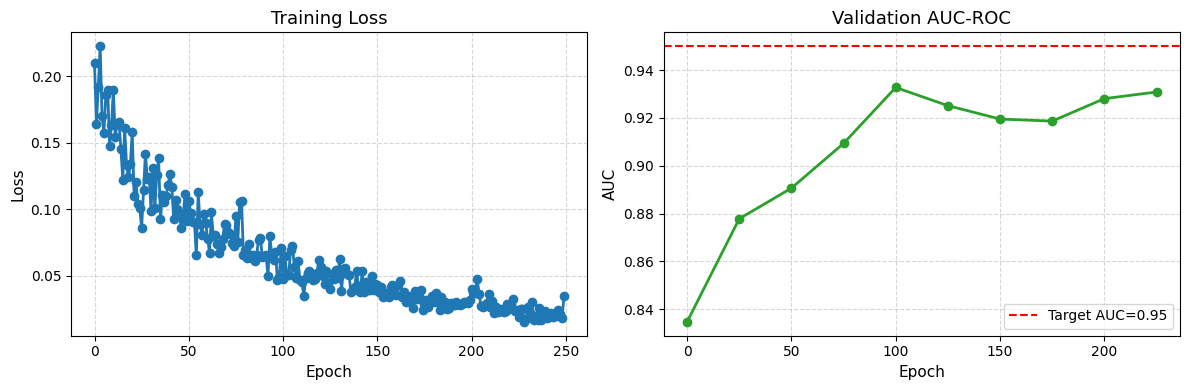

In [86]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o', linewidth=2, color='tab:blue')
plt.title('Training Loss', fontsize=13)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Loss', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot([i * eval_every for i in range(len(test_aucs))],
         test_aucs, 'o-', color='tab:green', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='Target AUC=0.95')
plt.title('Validation AUC-ROC', fontsize=13)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('AUC', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [87]:
get_score(auc)

np.float64(2.6162493612672444)

В итоге данная реализация триплет лоса вместе с моей моделью FaceEncoder выбивает скор AUC_ROC 0.93, то есть 2.6162493612672444 балла (2.6 балла). Считаю это очень хорошим результатом. Стоит заметить, что обучение на 50 эпохах заняло 15 минут, на 100 - 30 минут, 250 - 1 час 15 минут. На графиках видно, что лосс хоть и колеблется (что нормально для такой задачи), но глобально он уменьшается,а AUC-ROC глобально растет. Это подтверждает, что модель успешно обучилась.

In [72]:
torch.save(model, "face_encoder_full.pth")

##### [0.1 балла] Бонус: распознай себя

В качестве бонуса, загрузите свою фотографию (можно не одну), пропустите ее через модель и определите, на кого из известных людей, по мнению модели, вы больше всего похоже.

Ссылка на мои используемые здесь фото: https://drive.google.com/drive/folders/14YNLJNWFf5UUeyR0XjzEVvo_98qrFaLY?usp=sharing

Найдено фото: my_photo.jpg
Ищу самых похожих знаменитостей...

Топ-5 самых похожих людей:
--------------------------------------------------
1. Al_Gore: 1.000
2. Al_Sharpton: 1.000
3. Ali_Naimi: 1.000
4. Amelia_Vega: 1.000
5. Ana_Guevara: 1.000


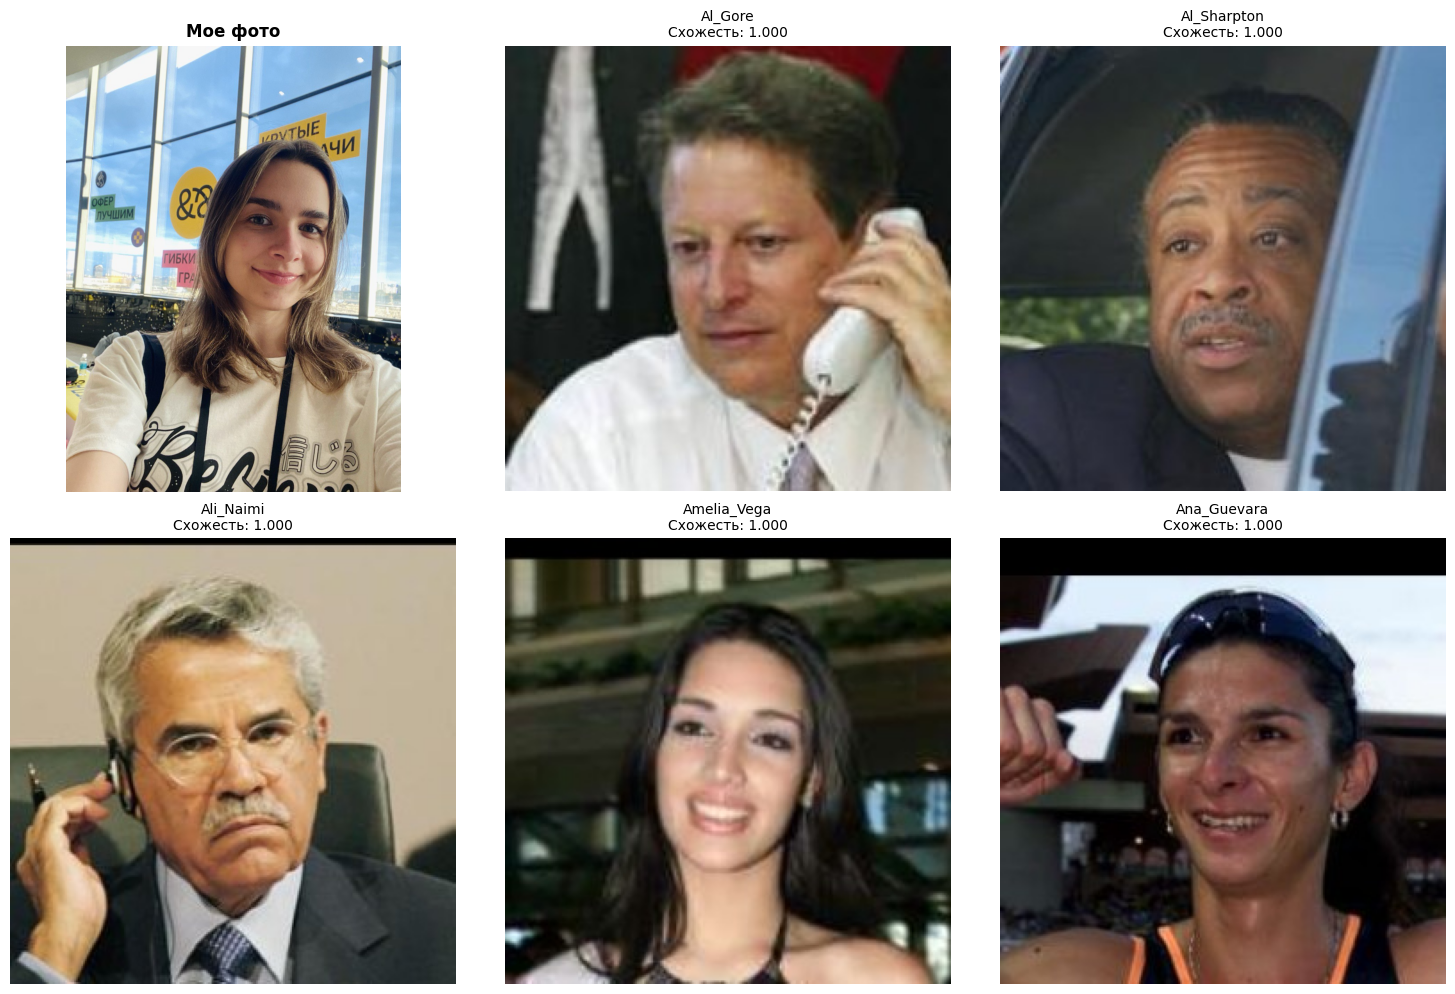


 Вы больше всего похожи на: Al_Gore
   Коэффициент схожести: 1.000


In [75]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import os

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((128, 128)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
])

def load_and_preprocess_image(image_path, transform):
    """Загрузка и предобработка изображения"""
    image = Image.open(image_path).convert('RGB')
    image = transform(image)
    return image.unsqueeze(0)

def find_most_similar_person(my_photo_path, model, dataset, transform, top_k=5):
    """
    Найти самых похожих людей на мою фотографию
    """
    model.eval()

    my_photo = load_and_preprocess_image(my_photo_path, transform)
    my_photo = my_photo.to(device)

    similarities = []

    with torch.no_grad():
        for person_id in range(len(dataset.classes)):
            person_similarities = []
            person_images = []

            for idx, (img, label) in enumerate(dataset):
                if label == person_id:
                    img_transformed = transform(Image.open(dataset.samples[idx][0]).convert('RGB'))
                    person_images.append(img_transformed)

            if not person_images:
                continue

            person_images = person_images[:3]  # Берем первые 3 фото
            person_batch = torch.stack(person_images).to(device)

            # Создаем пары: мое фото + фото человека
            my_photos_batch = my_photo.repeat(len(person_batch), 1, 1, 1)

            predictions = model(my_photos_batch, person_batch)

            avg_similarity = predictions.mean().item()

            person_name = dataset.classes[person_id]
            similarities.append((person_name, avg_similarity, person_id))

    similarities.sort(key=lambda x: 1 - x[1])

    return similarities[:top_k]

def visualize_similarity_results(my_photo_path, similarities, dataset, transform):
    """Визуализация моей фотографии и топ похожих людей"""

    my_photo = Image.open(my_photo_path).convert('RGB')

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    axes[0].imshow(my_photo)
    axes[0].set_title('Мое фото', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    for i, (person_name, similarity, person_id) in enumerate(similarities):
        person_image_path = None
        for idx, (img_path, label) in enumerate(dataset.samples):
            if label == person_id:
                person_image_path = img_path
                break

        if person_image_path is not None:
            person_img = Image.open(person_image_path).convert('RGB')

            axes[i+1].imshow(person_img)
            similarity_score = 1 - similarity
            axes[i+1].set_title(f'{person_name}\nСхожесть: {similarity_score:.3f}', fontsize=10)
            axes[i+1].axis('off')

    for i in range(len(similarities) + 1, 6):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()


def recognize_my_face(my_photo_path, model, dataset, transform, top_k=5):
    """
    Основная функция для распознавания: на кого я похож
    """
    print("Ищу самых похожих знаменитостей...")

    if not os.path.exists(my_photo_path):
        print(f"Файл {my_photo_path} не найден!")
        return None

    similarities = find_most_similar_person(my_photo_path, model, dataset, transform, top_k)

    print(f"\nТоп-{top_k} самых похожих людей:")
    print("-" * 50)

    for i, (person_name, similarity, person_id) in enumerate(similarities):
        similarity_score = 1 - similarity
        print(f"{i+1}. {person_name}: {similarity_score:.3f}")

    visualize_similarity_results(my_photo_path, similarities, dataset, transform)
    return similarities

dataset_for_search = torchvision.datasets.ImageFolder("data/training", transform=transform)
possible_photo_names = [
    'my_photo.jpg'
]

my_photo_path = None
for photo_name in possible_photo_names:
    if os.path.exists(photo_name):
        my_photo_path = photo_name
        print(f"Найдено фото: {photo_name}")
        break

if my_photo_path:
    try:
        results = recognize_my_face(my_photo_path, model, dataset_for_search, transform, top_k=5)

        if results:
            best_match = results[0]
            similarity_score = 1 - best_match[1]

            print(f"\n Вы больше всего похожи на: {best_match[0]}")
            print(f"   Коэффициент схожести: {similarity_score:.3f}")

    except Exception as e:
        print(f"Ошибка при обработке фото: {e}")

else:
    print("Фото не найдено.")

Действительно, с данными людьми некоторое сходство имеется!

Теперь сделаем все то же самое, но с другой моей фотографией (для эксперимента):

In [76]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((128, 128)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
])

def load_and_preprocess_image(image_path, transform):
    """Загрузка и предобработка изображения"""
    image = Image.open(image_path).convert('RGB')
    image = transform(image)
    return image.unsqueeze(0)

def find_most_similar_person(my_photo_path, model, dataset, transform, top_k=5):
    """
    Найти самых похожих людей на мою фотографию
    """
    model.eval()

    my_photo = load_and_preprocess_image(my_photo_path, transform)
    my_photo = my_photo.to(device)

    similarities = []

    with torch.no_grad():
        for person_id in range(len(dataset.classes)):
            person_similarities = []
            person_images = []

            for idx, (img, label) in enumerate(dataset):
                if label == person_id:
                    img_transformed = transform(Image.open(dataset.samples[idx][0]).convert('RGB'))
                    person_images.append(img_transformed)

            if not person_images:
                continue

            person_images = person_images[:3]
            person_batch = torch.stack(person_images).to(device)

            my_photos_batch = my_photo.repeat(len(person_batch), 1, 1, 1)

            predictions = model(my_photos_batch, person_batch)

            avg_similarity = predictions.mean().item()

            person_name = dataset.classes[person_id]
            similarities.append((person_name, avg_similarity, person_id))

    similarities.sort(key=lambda x: 1 - x[1])

    return similarities[:top_k]

def visualize_similarity_results(my_photo_path, similarities, dataset, transform):
    """Визуализация моей фотографии и топ похожих людей"""

    my_photo = Image.open(my_photo_path).convert('RGB')

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    axes[0].imshow(my_photo)
    axes[0].set_title('Мое фото', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    for i, (person_name, similarity, person_id) in enumerate(similarities):
        person_image_path = None
        for idx, (img_path, label) in enumerate(dataset.samples):
            if label == person_id:
                person_image_path = img_path
                break

        if person_image_path is not None:
            person_img = Image.open(person_image_path).convert('RGB')

            axes[i+1].imshow(person_img)
            similarity_score = 1 - similarity
            axes[i+1].set_title(f'{person_name}\nСхожесть: {similarity_score:.3f}', fontsize=10)
            axes[i+1].axis('off')

    for i in range(len(similarities) + 1, 6):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

In [77]:
def recognize_my_face(my_photo_path, model, dataset, transform, top_k=5):
    """
    Основная функция для распознавания: на кого я похож
    """
    print("Ищу самых похожих знаменитостей...")

    if not os.path.exists(my_photo_path):
        print(f"Файл {my_photo_path} не найден!")
        return None

    similarities = find_most_similar_person(my_photo_path, model, dataset, transform, top_k)

    print(f"\nТоп-{top_k} самых похожих людей:")
    print("-" * 50)

    for i, (person_name, similarity, person_id) in enumerate(similarities):
        similarity_score = 1 - similarity
        print(f"{i+1}. {person_name}: {similarity_score:.3f}")

    visualize_similarity_results(my_photo_path, similarities, dataset, transform)

    return similarities

Найдено фото: my_face.jpg
Ищу самых похожих знаменитостей...

Топ-5 самых похожих людей:
--------------------------------------------------
1. Al_Gore: 1.000
2. Al_Sharpton: 1.000
3. Ali_Naimi: 1.000
4. Amelia_Vega: 1.000
5. Ana_Guevara: 1.000


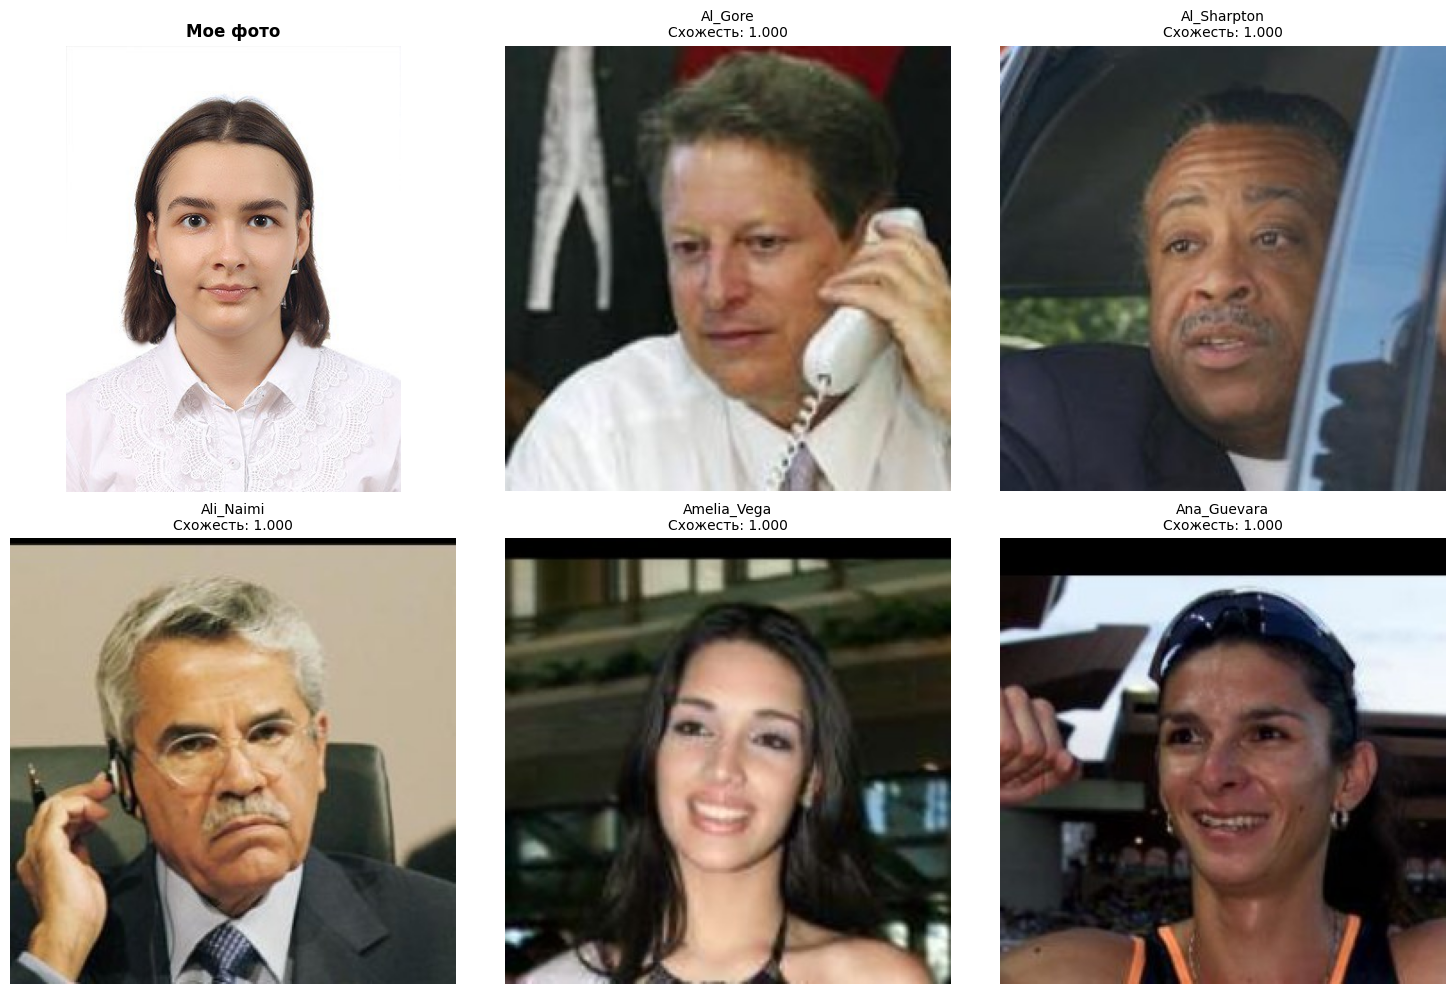


 Вы больше всего похожи на: Al_Gore
   Коэффициент схожести: 1.000


In [78]:
dataset_for_search = torchvision.datasets.ImageFolder("data/training", transform=transform)

possible_photo_names = [
   'my_face.jpg'
]

my_photo_path = None
for photo_name in possible_photo_names:
    if os.path.exists(photo_name):
        my_photo_path = photo_name
        print(f"Найдено фото: {photo_name}")
        break

if my_photo_path:
    try:
        results = recognize_my_face(my_photo_path, model, dataset_for_search, transform, top_k=5)

        if results:
            best_match = results[0]
            similarity_score = 1 - best_match[1]

            print(f"\n Вы больше всего похожи на: {best_match[0]}")
            print(f"   Коэффициент схожести: {similarity_score:.3f}")

    except Exception as e:
        print(f"Ошибка при обработке фото: {e}")

else:
    print("Фото не найдено.")

Во втором эксперименте среди топ-5 похожих знаменитостей оказались те же люди, что говорит о хорошей обощаемости модели и о том, что она четко поняла, что на двух разных фото один человек (я) и сопоставила его с одними людьми, которые визуально похожи. Так что эта модель работает, что радует)